In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
from torchvision.transforms.v2 import Compose, Normalize
from torch.utils.data import random_split

from sklearn.metrics import f1_score, confusion_matrix, classification_report

from train import StepByStep
import utils.overfit_single_batch as overfit_single_batch
from generate_lines import gen_img,plot_images
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Generate Dataset

class values [0 1 2 3]
number images per class [258 230 232 280]


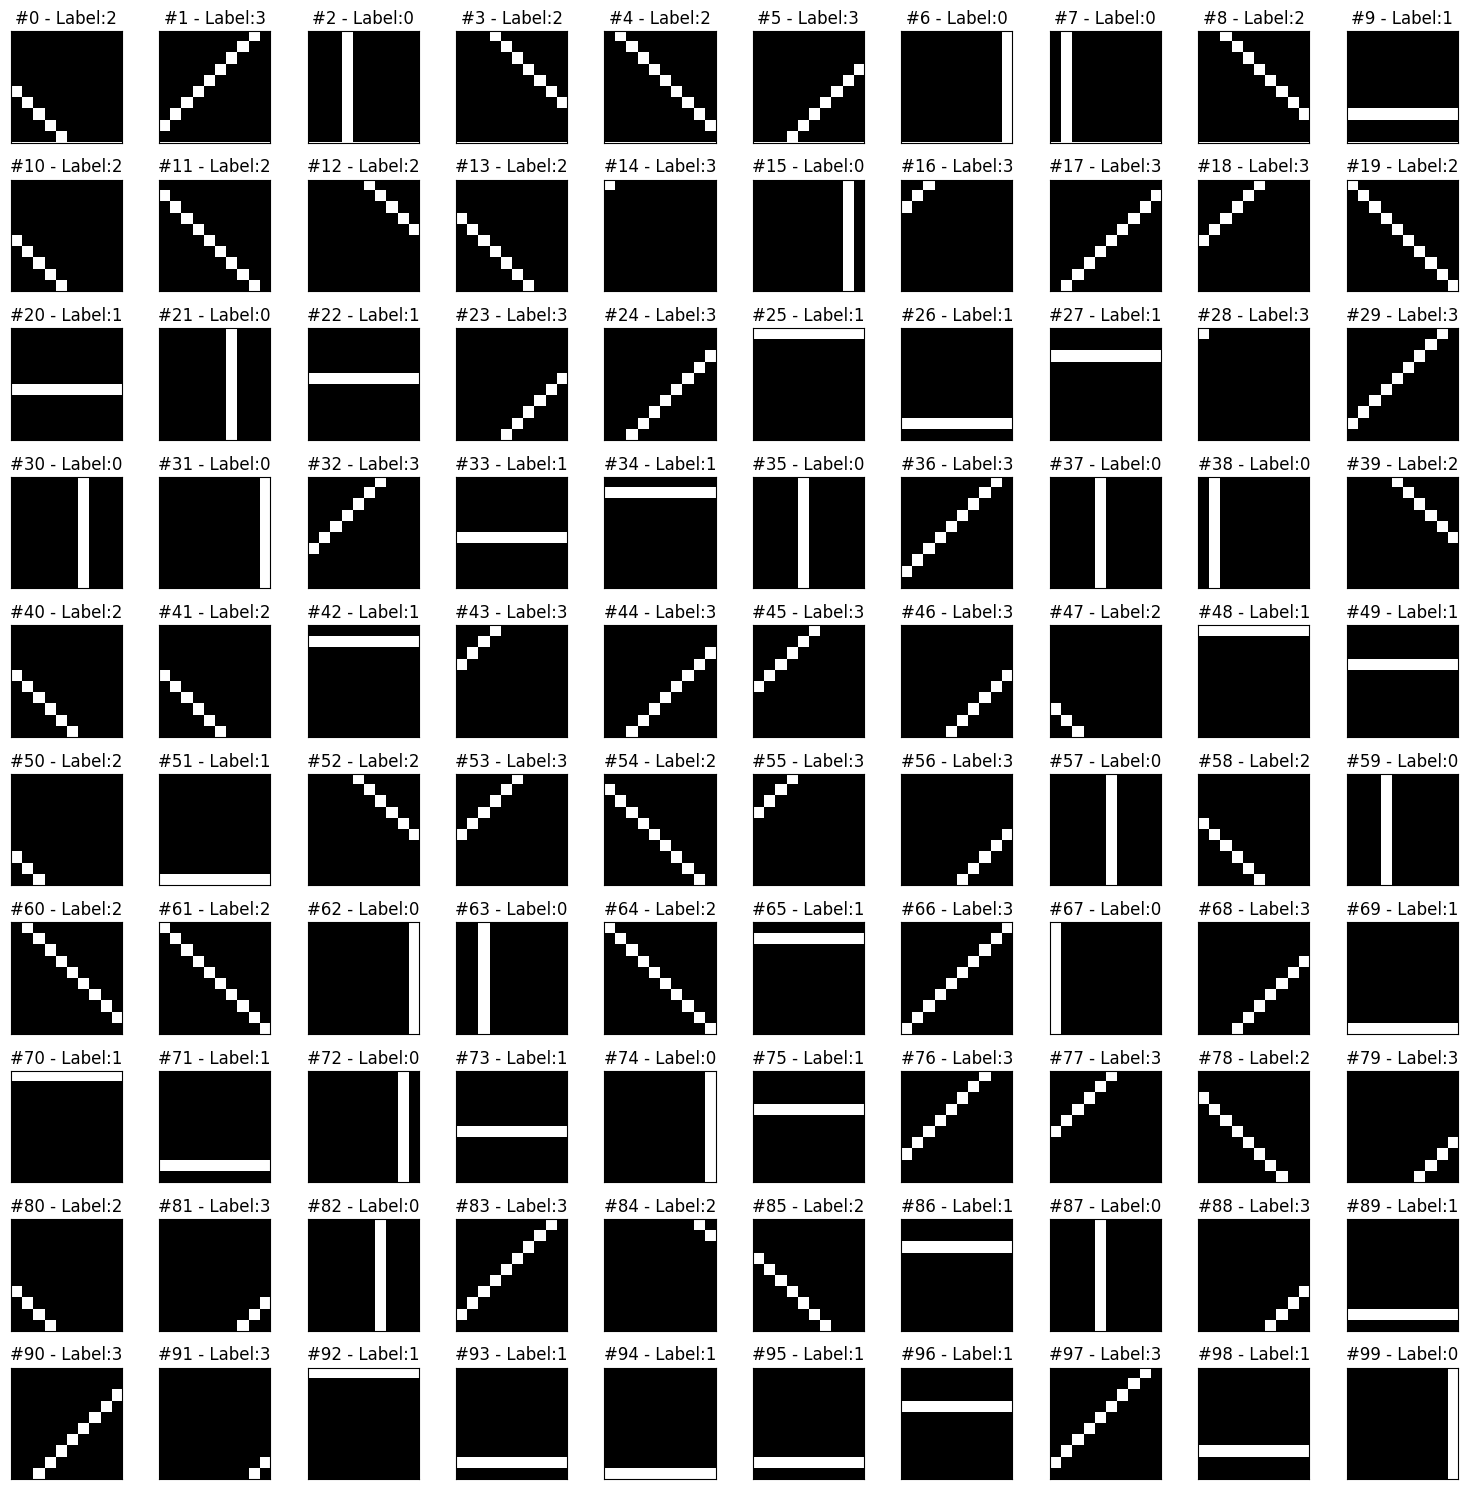

In [3]:
n_images=1000
img_size=10
SEED = 42
np.random.seed(SEED)
label=np.random.randint(low=0, high=4,size=n_images)
images = np.array([gen_img(img_size,target) for target in label],dtype=np.uint8)
plot_images(images,label, n_plot=100);

# check the data inbalance
values, counts = np.unique(label, return_counts=True)

print('class values',values)
print('number images per class',counts)

## Create TorchDataset

In [4]:
class DatasetTransform(Dataset):
    def __init__(self,x,y,transform=None):
        self.x=x
        self.y=y
        self.transform=transform
    def __getitem__(self, index):
        x=self.x[index]
        if self.transform:
            x=self.transform(x)
        return x, self.y[index]
    
    def __len__(self):
        return len(self.x)


x_tensor=torch.as_tensor(images).float()
y_tensor=torch.as_tensor(label).long()

### Split train and validation set
n = len(x_tensor)
# Create reproducible random indices
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(n, generator=generator)

# 80% train, 20% validation
train_size = int(0.8 * n)

train_idx = indices[:train_size]
val_idx = indices[train_size:]

# Use the same indices for X and y
x_train = x_tensor[train_idx]
y_train = y_tensor[train_idx]

x_val = x_tensor[val_idx]
y_val = y_tensor[val_idx]

compose = Compose([Normalize(mean=[0.5], std=[0.5])])
train_dataset= DatasetTransform(x_train,y_train,compose)
val_dataset= DatasetTransform(x_val,y_val,compose)

train_loader = DataLoader(dataset=train_dataset, batch_size=16,shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16,shuffle=False)

## Model

In [5]:
class ConvNet(nn.Module):
    def __init__(self):
            super().__init__()
         
            self.conv1=nn.Conv2d(in_channels=1,out_channels=3,kernel_size=3)
            self.bn_conv1 = nn.BatchNorm2d(num_features=3)
            self.relu1=nn.ReLU()

            self.conv2=nn.Conv2d(in_channels=3,out_channels=5,kernel_size=3)
            self.bn_conv2 = nn.BatchNorm2d(num_features=5)
            self.relu2=nn.ReLU()

            self.maxpool1=nn.MaxPool2d(kernel_size=2)
            self.flatten=nn.Flatten()

            self.linear1=nn.Linear(in_features=5*3*3, out_features=10)
            self.linear2=nn.Linear(in_features=10,out_features=4)


    def forward(self,x):
          x=self.conv1(x)
          x=self.bn_conv1(x)
          x=self.relu1(x)

          x=self.conv2(x)
          x=self.bn_conv2(x)
          x=self.relu2(x)
          
          x=self.maxpool1(x)
          x=self.flatten(x)
          x=self.linear1(x)
          x=self.linear2(x)
          return x


In [7]:
# # # model check
# #print(model_checks.count_parameters(model))
# model=ConvNet()

# x=torch.rand((1,1,10,10))  # (N,C,H,W)

# B,C,H,W=x.shape
# print(f"batch={B},chanels={C}, Hight={H}, Width={W}")
# x=model.conv1(x)
# x=model.bn_conv1(x)
# x=model.relu1(x)

# x=model.conv2(x)
# x=model.bn_conv2(x)
# x=model.relu2(x)

          
# x=model.maxpool1(x)
# x=model.flatten(x)
# x=model.linear1(x)
# x=model.linear2(x)

In [8]:
# loss_fn = nn.CrossEntropyLoss()
# model_checks.overfit_single_batch(model,loss_fn=loss_fn,train_loader=train_loader,epochs=1000)

## Training

In [10]:
# 3. Initialize components
seed = 42
lr = 1e-3  # Added default learning rate definition


model = ConvNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.5*1e-3)

sbs = StepByStep(model, loss_fn, optimizer)
sbs.set_loaders(train_loader, val_loader)
#sbs.set_tensorboard('Baseline')

Epoch [0/100] -> Train Loss: 1.3548 | Val Loss: 1.2887 | F1_ score: 0.2511
Epoch [1/100] -> Train Loss: 1.1846 | Val Loss: 1.1049 | F1_ score: 0.3831
Epoch [2/100] -> Train Loss: 1.0151 | Val Loss: 0.9571 | F1_ score: 0.5330
Epoch [3/100] -> Train Loss: 0.8783 | Val Loss: 0.8036 | F1_ score: 0.7606
Epoch [4/100] -> Train Loss: 0.7415 | Val Loss: 0.6419 | F1_ score: 0.8586
Epoch [5/100] -> Train Loss: 0.5795 | Val Loss: 0.5150 | F1_ score: 0.9499
Epoch [6/100] -> Train Loss: 0.4779 | Val Loss: 0.4319 | F1_ score: 0.9499
Epoch [7/100] -> Train Loss: 0.3892 | Val Loss: 0.3583 | F1_ score: 0.9673
Epoch [8/100] -> Train Loss: 0.3370 | Val Loss: 0.2988 | F1_ score: 0.9721
Epoch [9/100] -> Train Loss: 0.2625 | Val Loss: 0.2552 | F1_ score: 0.9778
Epoch [10/100] -> Train Loss: 0.2141 | Val Loss: 0.2115 | F1_ score: 0.9835
Epoch [11/100] -> Train Loss: 0.1847 | Val Loss: 0.1776 | F1_ score: 0.9835
Epoch [12/100] -> Train Loss: 0.1513 | Val Loss: 0.1516 | F1_ score: 0.9945
Epoch [13/100] -> Trai

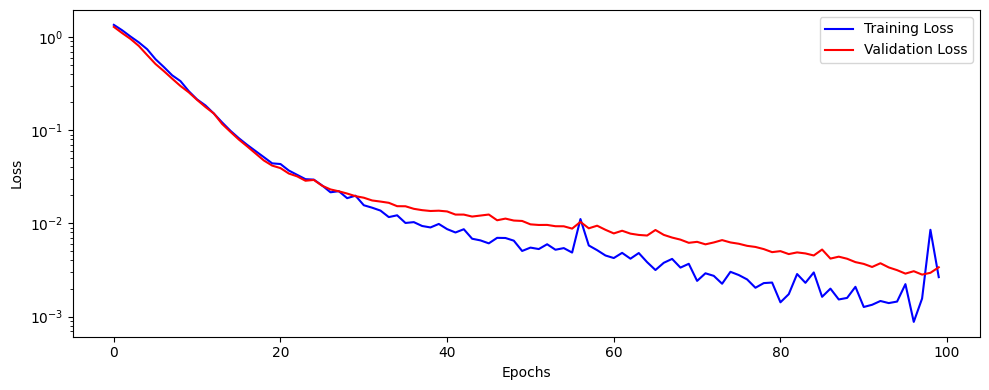

In [11]:
sbs.train(n_epochs=100)
sbs.plot_losses();

In [1]:
sbs.plot_losses();

NameError: name 'sbs' is not defined

In [12]:
for key, value in sbs.val_report[-1].items():
    print(value)
    

1.0
[[55  0  0  0]
 [ 0 52  0  0]
 [ 0  0 40  0]
 [ 0  0  0 53]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        40
           3       1.00      1.00      1.00        53

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [13]:
#!tensorboard --logdir=runs

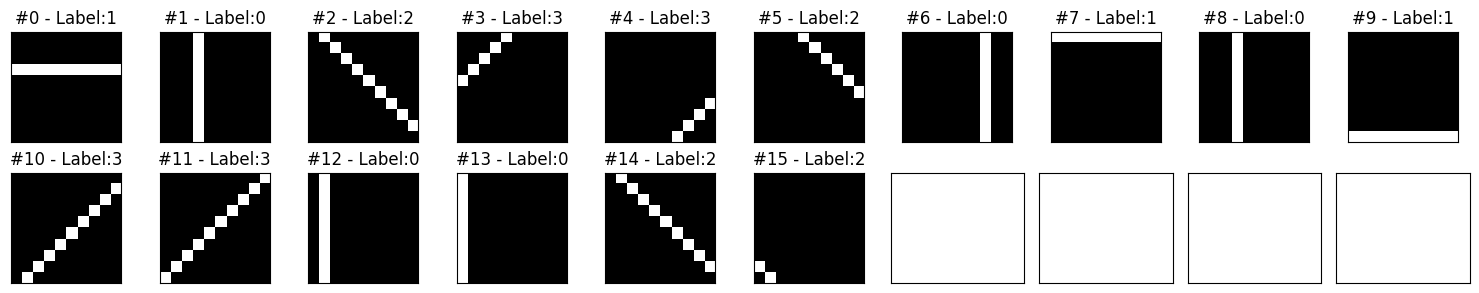

In [14]:
images_batch, labels_batch = next(iter(val_loader))
plot_images(images_batch,labels_batch, n_plot=16);

In [15]:
import ipywidgets as widgets
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display, clear_output



images_batch, labels_batch = next(iter(val_loader))
#plot_images(images_batch,labels_batch, n_plot=16);


layers_to_hook=['conv1','relu1','conv2','relu2','maxpool1', 'flatten', 'linear1', 'linear2']
sbs.attach_hooks(layers_to_hook)
logits = sbs.predict(images_batch)
#sbs._visualize_output(images_batch,labels_batch,1)
#sbs.remove_hooks()


out = widgets.Output()

def show_image(idx):
    with out:
        clear_output(wait=True)
        sbs._visualize_one_output(images_batch, labels_batch, idx)
        plt.show()

slider = widgets.IntSlider(
    min=0, max=len(images_batch) - 1, step=1, value=0,
    description='Image #', continuous_update=False
)

widgets.interactive_output(show_image, {'idx': slider})
display(slider, out)

IntSlider(value=0, continuous_update=False, description='Image #', max=15)

Output()

torch.Size([5, 3, 3, 3])

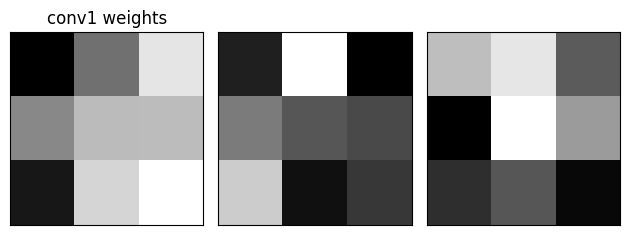

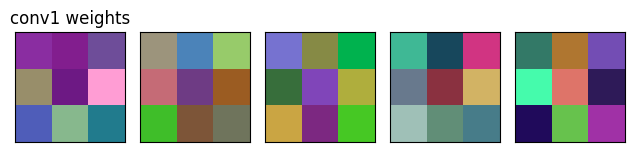

In [16]:
sbs._visualize_tensor(model.conv1.weight.detach().squeeze(1), note="conv1 weights",filters=True)
sbs._visualize_tensor(model.conv2.weight.detach().squeeze(1), note="conv1 weights",filters=True)
model.conv2.weight.detach().squeeze(1).shape

In [17]:
for x, y in val_loader:
    logits = sbs.predict(x)
    pred_class = logits.argmax(axis=1)
    y=y.numpy()

    # if pred_class is a torch tensor and y is a torch tensor:
    
    mismatch_idx =np.where(pred_class-y!=0)[0]

    if len(mismatch_idx) > 0:
        for i in mismatch_idx:
            print(f" predicted = {pred_class[i]}, true_class={y[i]}")
            sbs._visualize_one_output(x, y, i)
    
      